
**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.
# Deploy, monitoramento e aprendizado contínuo — proposta documental

## Objetivo

Explicar como a solução poderia ser publicada, observada, atualizada e revertida. Esta etapa é **somente documentação**: nenhum serviço foi publicado, nenhuma infraestrutura foi provisionada e nenhum reentreinamento automático foi implementado. O modelo local avaliado existe; a API e a imagem citadas abaixo são as propostas do notebook 07.

## 1. Arquitetura proposta

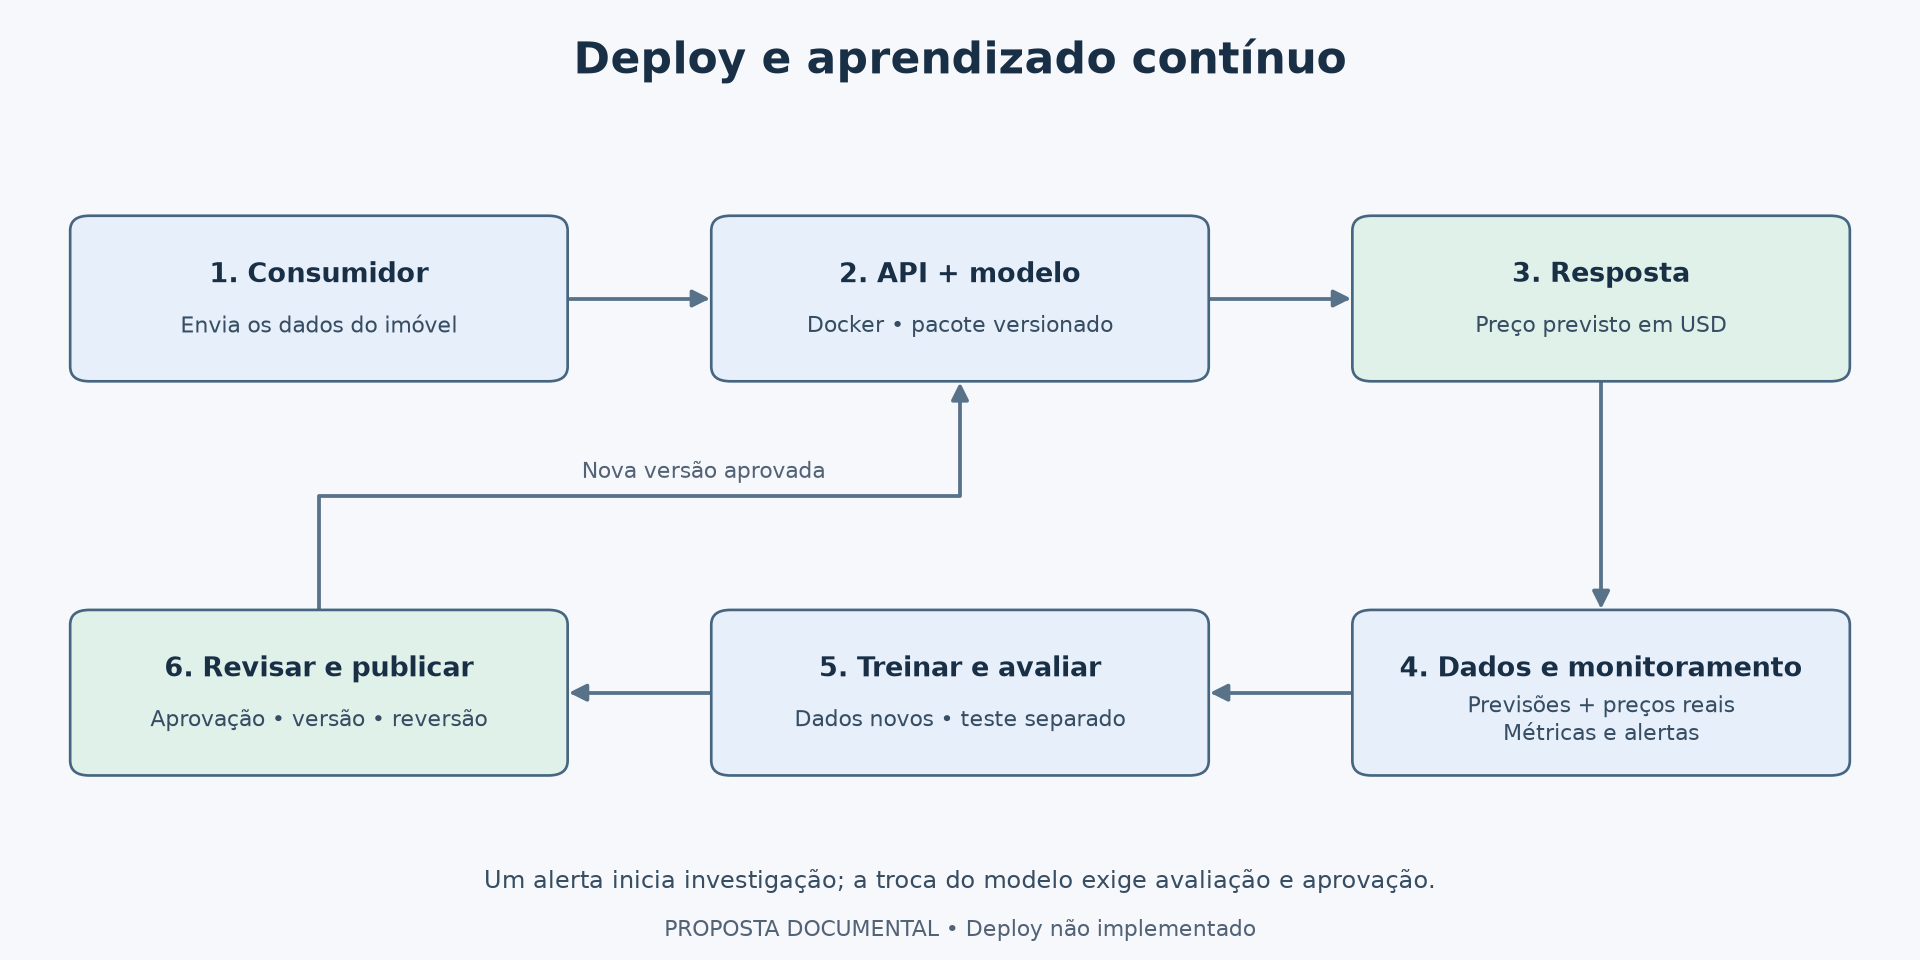

*Esquema da arquitetura proposta; não representa serviços já implantados.*

Leitura do diagrama: o consumidor envia os dados à API e recebe o preço previsto. As previsões, os preços reais disponíveis e o monitoramento ajudam a identificar necessidade de melhoria. Quando justificado, um candidato é treinado e avaliado com dados novos; só uma versão aprovada substitui a anterior. Alertas iniciam investigação, não promoção automática. Autenticação, integração opcional com LLM, MLflow e infraestrutura estão detalhados nas seções seguintes.

| Camada | Responsabilidade | Justificativa |
|---|---|---|
| Entrada HTTPS/autenticação | Controlar acesso e tráfego | Expor o serviço de forma controlada |
| API e pacote de inferência | Validar, enriquecer, transformar e prever | Manter a lógica compatível com a avaliação |
| Serviço de contêineres | Executar e reiniciar instâncias; encaminhar tráfego somente às prontas | Separar operação da sessão de notebook |
| Registro de releases | Guardar imagem e referências dos componentes | Publicar e reverter um conjunto identificável |
| Observabilidade | Medir saúde, entradas e desempenho conhecido | Detectar falhas e orientar investigação |
| Armazenamento de feedback | Associar previsão e preço realizado | Permitir medir desempenho real depois da venda |
| Treinamento separado | Produzir e avaliar candidatos | Não interromper nem alterar o modelo durante uma requisição |

## 2. Infraestrutura inicial e publicação

A opção inicial seria um serviço gerenciado de contêineres com registro privado e armazenamento controlado de artefatos e feedback. O provedor dependeria do ambiente do cliente; não há necessidade demonstrada de Kubernetes para o volume deste desafio. Não foram estimados preço mensal, disponibilidade contratual ou capacidade de requisições.

**Configuração inicial para ensaio:** um processo por contêiner, até duas threads de inferência, carregamento do pacote na inicialização e tráfego liberado somente após `GET /ready`. Réplicas e limites de CPU/memória seriam definidos após medir carga, latência e consumo. Segredos de acesso seriam fornecidos pelo ambiente, não gravados na imagem ou no repositório.

**Fluxo futuro de publicação:** revisão do código e do contrato → verificações de equivalência → construção da imagem → armazenamento por digest → homologação com casos conhecidos → revisão das pendências → liberação controlada. Uma alteração de empacotamento sem mudar modelo/dados deve reproduzir previsões; uma alteração de modelo ou snapshot exige também avaliação preditiva.

Durante uma liberação inicial, uma versão candidata poderia atender uma pequena parcela do tráfego ou receber cópias de requisições sem responder ao cliente. O percentual seria acordado conforme o risco. Latência e erros podem ser verificados imediatamente; a qualidade dos preços só pode ser verificada quando os valores reais chegam.

## 3. Monitoramento: três perguntas diferentes

| Pergunta | Indicadores propostos | Resposta prevista |
|---|---|---|
| O serviço está funcionando? | Taxa de falhas, latência p50/p95, disponibilidade, CPU, memória e prontidão | Investigar aplicação, recursos ou release |
| As entradas mudaram? | Ausências, rejeições, CEPs não suportados, distribuições de áreas, grade e previsões | Verificar integração, cobertura e mudança de população |
| O modelo continua útil? | MAE, RMSE, viés, erro percentual mediano e proporção dentro das tolerâncias acordadas | Investigar desempenho quando houver preço real |

**Leitura das métricas do serviço:** latência é o tempo de resposta; p50 é a mediana e p95 é o tempo abaixo do qual ficaram 95% das requisições observadas.

**Mudança de distribuição não prova perda de qualidade.** Pode haver mudança nas entradas sem aumento do erro, ou piora de erro sem uma mudança óbvia em uma coluna. Avaliaríamos indicadores em conjunto, por período e segmento, sempre informando a quantidade de observações.

As referências iniciais viriam dos dados e métricas documentados, mas limites de alerta, frequência e duração mínima seriam calibrados no contexto real. Não propomos usar automaticamente MAE de 74.089 como limite de aceitação: esse número é um resultado histórico, não um compromisso de negócio.

Nos logs operacionais, usaríamos `request_id`, status, duração e versões. Os dados necessários a feedback ficariam em armazenamento separado com acesso e retenção definidos. CEP ou identificadores individuais não seriam rótulos de métricas para cada requisição; os relatórios regionais seriam agregados.

## 4. Versionamento da solução completa

Uma **versão do modelo** identifica o estimador; uma **release do serviço** identifica o conjunto utilizado para atender uma requisição. O registro proposto conteria:

| Item | Referência a guardar |
|---|---|
| Código de preparo e API | Commit ou identificador imutável |
| Modelo e pipeline | Versão, arquivo e hash |
| Contrato | Versão do esquema de entrada e ordem das features |
| Demografia | Snapshot, origem, período de referência e hash |
| Ambiente | Python, dependências e imagem por digest |
| Avaliação | Dados/partições, métricas, limitações e responsável pela revisão |

Atualmente, parte dessa rastreabilidade está nos JSONs locais, em especial `artifacts/model_card.json` e `reports/metrics/avaliacao_registro.json`. Para organizar experimentos e modelos em uma implementação futura, propomos MLflow Tracking e Model Registry, conforme detalhado abaixo. Nenhuma integração com MLflow foi executada nesta entrega.

Uma atualização do snapshot demográfico não seria uma edição livre da tabela em produção. A nova versão passaria por conferência de cobertura, significado, período e efeito nas previsões, mantendo acesso à versão anterior.

### Como essa organização seria feita no MLflow

**MLflow é a ferramenta proposta para organizar os experimentos e o registro de modelos.** Os arquivos locais representam o que já foi produzido nesta entrega; não substituem conceitualmente o MLflow nem indicam que ele tenha sido utilizado. A integração abaixo é somente documentação, sem instalação, migração ou execução de um servidor.

**Tracking** organiza experimentos e suas execuções (*runs*), registrando parâmetros, métricas e artefatos. **Model Registry** organiza modelos registrados e suas versões, vinculadas à origem. Registrar um modelo não significa aprová-lo para produção. Referências: [MLflow Tracking](https://mlflow.org/docs/latest/ml/tracking/) e [Model Registry](https://mlflow.org/docs/latest/ml/model-registry).

| O que temos no projeto | Como seria organizado no MLflow |
|---|---|
| Configurações comparadas no notebook 05 | Experimento de seleção, com uma execução por configuração completa; métricas de cada janela e média identificadas |
| Tentativas do Optuna | Execuções relacionadas à busca; registrar parâmetros e distinguir tentativas completas das interrompidas |
| MAE, RMSE e R² dos notebooks 05 e 06 | Métricas com nomes distintos, como `cv_mae_mean` e `test_mae`, sem misturar avaliação final com seleção |
| Gráficos, tabelas e explicações | Artefatos associados à execução correspondente |
| `artifacts/modelo_avaliado.joblib` | Pipeline completo avaliado registrado como modelo, não apenas o estimador LightGBM interno |
| `model_card.json` e `avaliacao_registro.json` | Manifestos anexados; identificadores e informações de consulta também poderiam ser tags |
| Contrato das 50 entradas | Assinatura do modelo e exemplo de entrada preparados para essa interface |
| Identificação da demografia e dos dados | Referências de snapshots e hashes, com os arquivos mantidos em armazenamento controlado |

**Exemplo de organização, ainda não criado:** experimento `house_price_selection` para comparações, uma execução identificada como avaliação final e modelo registrado `house_price_regressor`. O registro relacionaria a versão ao pipeline treinado no 06. Não registraríamos os modelos de cada janela como se fossem o estimador final: eles foram treinados com conjuntos diferentes.

### Versão, alias e release: qual é a diferença?

Uma versão do registro identifica um modelo. Um **alias** é um nome que aponta para uma versão e pode ser redirecionado, como `champion`. Podemos usar tags para indicar revisão pendente ou aprovada. A documentação atual orienta o uso de aliases e tags em substituição ao fluxo antigo baseado em stages. [Fluxos do Model Registry](https://www.mlflow.org/docs/latest/ml/model-registry/workflow/).

**Exemplo hipotético:** `house_price_regressor`, versão 1, poderia receber o alias `champion` depois da aprovação. Um novo candidato seria registrado como outra versão, avaliado e revisado. Nenhuma dessas versões ou aprovações existe hoje no MLflow deste projeto. O identificador local `avaliacao_v1` não corresponde automaticamente à versão 1 de um registro MLflow.

Na publicação proposta, resolveríamos o alias para uma **versão exata** e guardaríamos essa referência no manifesto da release. A imagem incorporaria o artefato correspondente e seu snapshot. Não consultaríamos o alias a cada previsão. Assim, trocar o alias sozinho não substituiria silenciosamente o modelo já carregado no contêiner; a atualização passaria pelo fluxo controlado de publicação.

| MLflow registraria | A release do serviço também precisaria associar |
|---|---|
| Nome e versão do modelo, execução de origem e metadados | Código da API e das transformações por linha |
| Pipeline ajustado e contrato das entradas preparadas | Versão da demografia usada na junção |
| Métricas e artefatos de avaliação | Imagem Docker por digest e configuração operacional |

**Por que isso importa aqui:** o pipeline atual recebe 50 features prontas. A assinatura desse modelo no MLflow não deve afirmar que ele recebe somente as 18 características físicas. A API é que faria a junção e as derivadas. Se no futuro todo esse preparo fosse encapsulado em outro artefato, sua interface e equivalência precisariam ser verificadas antes de registrá-lo como uma nova versão.

### Fluxo proposto de registro e promoção

1. Registrar parâmetros, partições e métricas durante os experimentos de treino e validação.
2. Associar o modelo final e o relatório do teste à execução de avaliação, preservando que o teste já foi examinado.
3. Registrar o candidato e seu manifesto, sem marcar automaticamente como aprovado.
4. Após os critérios de dados, negócio e operação serem atendidos, selecionar a versão e construir a release correspondente.
5. Guardar a versão anterior do modelo e da release para reversão do conjunto completo.

Migrar os arquivos atuais para o MLflow não exigiria treinar novamente. Essa importação precisaria ser identificada como posterior à execução original, preservando datas e evidências, em vez de simular que o rastreamento ocorreu durante o treinamento.

Para uma implantação compartilhada, o servidor precisaria de banco para metadados e armazenamento de artefatos, com acesso e cópias de segurança definidos. O registro via servidor próprio requer backend baseado em banco de dados. Isso também permanece proposto, sem serviço provisionado. [Requisito do registro](https://www.mlflow.org/docs/latest/ml/model-registry/workflow/).

**Como explicar na entrevista:** “Usaria MLflow Tracking para comparar experimentos e o Model Registry para identificar os candidatos e suas versões. A release fixaria a versão aprovada junto com o código, o contrato e a demografia. Nesta entrega, essas evidências estão em arquivos locais; a integração com MLflow está documentada.”


## 5. Como chegar o feedback de novas vendas

O sistema consumidor precisaria fornecer um identificador persistente do imóvel ou da oportunidade de venda, separado das features. O `request_id` identifica uma tentativa de previsão e, sozinho, não associa automaticamente uma venda futura ao imóvel.

No momento da previsão, seriam guardados de forma controlada: identificador do evento, instante, entradas disponíveis naquele instante, preço previsto e versões. Quando a venda ocorresse, chegariam preço realizado, data da venda e data em que essa informação ficou disponível.

Se houvesse várias previsões para a mesma venda, usaríamos uma regra de associação definida previamente, por exemplo a última previsão válida anterior à venda dentro de um horizonte acordado. Duplicidades, correções de preço e vendas canceladas seriam tratados antes de calcular métricas.

**Por que registrar as duas datas:** a venda pode ter ocorrido antes de seu preço ser conhecido pelo sistema. Treinar com rótulos ainda indisponíveis na data simulada criaria informação do futuro. Além disso, o feedback inclui apenas imóveis que efetivamente venderam; isso pode não representar todas as consultas recebidas.

## 6. Reentreinamento: aprender em lotes, não a cada requisição

O modelo não aprenderia automaticamente a cada previsão. A proposta é produzir candidatos em execuções separadas, quando houver novas vendas rotuladas suficientes e confiáveis.

1. **Revisar a necessidade:** uma revisão mensal seria um ponto de partida, a ajustar ao volume. Um alerta também pode motivar investigação; não obriga reentreinar.
2. **Preparar dados:** validar rótulos, duplicidades e datas de disponibilidade; recuperar as características e a demografia disponíveis na época de cada previsão.
3. **Separar cronologicamente:** usar passado para treinamento e validação; reservar um período recente independente, preservando o controle de imóveis repetidos e eventual atraso dos rótulos.
4. **Treinar candidatos com orçamento:** comparar a receita atual com mudanças justificadas; aprender imputação e codificação apenas em cada treino.
5. **Comparar:** executar candidato e modelo vigente nas mesmas vendas reservadas, com a preparação própria de cada release, medindo erro geral, subestimação, segmentos e custo operacional.
6. **Revisar a decisão:** promover somente se cumprir critérios previamente acordados; guardar também os candidatos rejeitados e suas evidências.

O teste usado no notebook 06 já foi examinado e não seria apresentado como uma nova confirmação independente. Para a próxima versão, precisaríamos de um período novo ainda reservado. Sem novos dados adequados, uma melhoria nas janelas antigas continuaria sendo evidência de desenvolvimento, não uma garantia de generalização.

## 7. Critérios de promoção, reversão e responsáveis

**Promoção proposta:** antes de abrir a nova avaliação, ciência de dados e negócio definiriam tolerâncias para MAE, viés e segmentos prioritários; engenharia definiria limites operacionais. A decisão consideraria melhora ou manutenção aceitável, cobertura e confiabilidade dos dados. Não há valores aprovados desses critérios no desafio.

**Reversão:** manter a imagem anterior e o pacote completo associado. Em caso de erro de carregamento, falhas ou mudança inesperada nas previsões, redirecionar o tráfego para a release anterior pronta e investigar. Reverter só o joblib, mantendo demografia ou features incompatíveis, não é uma reversão confiável. Não existe hoje uma release de produção anterior: esse mecanismo é uma proposta.

| Responsável proposto | Atribuição |
|---|---|
| Ciência de dados | Avaliar erro, segmentos, mudanças e candidatos |
| Engenharia de software/plataforma | Contrato, disponibilidade, publicação e reversão |
| Responsável pelos dados | Origem, significado, disponibilidade e correções |
| Responsável de negócio | Uso da estimativa, tolerâncias e aprovação de mudanças |

## 8. Pendências e limites antes de operar

O modelo local teve MAE de teste de 74.089 e tendência de subestimação, especialmente nos imóveis caros. A origem e o período da demografia permanecem pendentes. É necessário definir tolerância de erro, cobertura mínima das entradas, política para CEP não suportado e proteção do histórico de feedback.

Implementar e verificar o serviço, sua imagem e as rotinas de publicação seriam trabalhos futuros. O deploy está descrito, não realizado. A seção de Docker e referências técnicas está em [packaging_api.md](../docs/packaging_api.md).

**Próximo passo do desafio:** consolidar a comunicação para stakeholders no notebook 09, usando os resultados observados e este desenho de operação.

## 9. Operação da integração com a API de LLM

A API externa de LLM está incluída na arquitetura proposta para contemplar a integração com APIs de IA mencionada no objetivo geral. Seu contrato e o fluxo de explicação estão na seção 9 de [packaging_api.md](../docs/packaging_api.md). O desenho continua sendo somente documental.

**Separação operacional:** a indisponibilidade da LLM desabilitaria a explicação gerada, mas não a prontidão do cálculo de preços se modelo, esquema e snapshot estiverem íntegros. O serviço retornaria o preço válido com texto de contingência e estado explícito. A situação do provedor seria monitorada separadamente. Falha do LightGBM não seria encoberta por uma resposta da LLM.

| Indicador proposto | Por que acompanhar |
|---|---|
| Latência da geração e da resposta completa | Verificar quanto a explicação acrescenta ao tempo de atendimento |
| Erros, timeouts e respostas inválidas | Identificar indisponibilidade ou incompatibilidade da integração |
| Proporção de contingências | Medir quantos pedidos de explicação não receberam texto gerado válido |
| Tokens de entrada e saída, quando informados pelo provedor | Estimar consumo e aplicar orçamento |
| Custo estimado por explicação e período | Comparar uso com orçamento, usando a tarifa vigente registrada |
| Divergências numéricas e falhas em revisão de conteúdo | Monitorar fidelidade e utilidade do texto |

Os limiares seriam definidos após ensaios. Não há preço, latência ou qualidade de geração medidos neste projeto. O tempo de inferência local não estima o tempo de uma chamada externa.

**Credenciais e registros:** a chave seria fornecida por gestão de segredos do ambiente, com acesso restrito e rotação. Não entraria no Dockerfile, notebook ou Git. O identificador de correlação ligaria inferência e geração; os logs registrariam status, duração, versões e consumo disponível, sem gravar por padrão prompts completos ou dados detalhados dos imóveis. Uso e retenção de dados pelo provedor precisariam ser verificados antes de ativar a integração.

**Versionamento:** cada geração registraria versão do prompt, esquema de contexto, modelo/provedor e versão do regressor. Atualizar apenas a LLM ou seu prompt também exige avaliação do texto. Quando o provedor permitir fixar uma versão, ela seria preferida para reduzir mudanças inesperadas; essa capacidade seria confirmada na contratação, não presumida.

**Avaliação antes de liberar:** criar um conjunto de casos com fatos e restrições esperadas, incluindo ausências, preços extremos, explicações indisponíveis e falhas externas. Verificar preservação de valores, ausência de afirmações não sustentadas e clareza, combinando verificações automáticas com revisão humana. MAE avalia o regressor; não mede a qualidade da explicação em linguagem natural.

**Reversão:** um problema na geração permitiria desativá-la ou restaurar a combinação anterior de prompt e modelo de linguagem, mantendo a release numérica avaliada. A resposta de contingência precisaria continuar disponível. O reentreinamento do LightGBM seguiria o processo de vendas reais descrito neste documento; textos gerados pela LLM não seriam usados como preços verdadeiros.

**Métrica complementar de qualidade:** acompanharíamos também MAPE (%) quando os preços reais estivessem disponíveis, junto de MAE em USD e viés. A referência histórica do LightGBM no teste é 12,77%, sem representar limite de aceitação. Preços reais nulos, negativos ou ausentes seriam sinalizados, sem cálculo silencioso de percentual inválido.
